<a href="https://colab.research.google.com/github/Sanskruti236/ML-Practical/blob/main/Practical_No_9_Roll_No_519.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
#print(np.__version__)

In [2]:
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    def forward(self, input):
        pass

    def backward(self,output_gradient, learning_rate):
        pass

In [3]:
weight_list = []
bias_list = []

In [4]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        self.weights = np.random.randn(output_size, input_size)
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, input_gradient):
        weights_gradient = np.dot(output_gradient, self.input.T)
        input_gradient = np.dot(self.weights.T, output_gradient)

        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient

        weight_list.append(self.weights)
        bias_list.append(self.bias)

        return input_gradient

In [5]:
def mse(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    return 2 * (y_pred - y_true) / np.size(y_true)

In [6]:
class Activation(Layer):
    def __init__(self, activation, activation_prime):
        self.activation = activation
        self.activation_prime = activation_prime

    def forward(self, input):
        self.input = input
        return self.activation(self.input)

    def backward(self, output_gradient, learning_rate):
        return np.multiply(output_gradient, self.activation_prime(self.input))

In [7]:
class Linear(Activation):
    def __init__(self):
        def linear(x):
            return x

        def linear_prime(x):
            return 1

        super().__init__(linear, linear_prime)

In [8]:
X = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
Y =  np.array([1.2, 1.4, 1.55, 1.75, 2.01, 2.2, 2.35])

network = [
    Dense(1, 1),
    Linear()
]

epochs = 100
learning_rate = 0.5
errorlist = []

for e in range(epochs):
    error = 0
    for x,y in zip(X,Y):
        output = x
        for layer in network:
            output=layer.forward(output)
        error += mse(y,output)
        grad = mse_prime(y,output)

        for layer in reversed(network):
            grad = layer.backward(grad, learning_rate)

    print(f"{e + 1}/({epochs}, error={error}")
    errorlist.append(error)

1/(100, error=6.378279439378352
2/(100, error=1.2917154802873274
3/(100, error=0.9314715553839433
4/(100, error=0.6730856338004431
5/(100, error=0.4876438879157814
6/(100, error=0.3544588628897131
7/(100, error=0.2587250019927828
8/(100, error=0.1898439943179437
9/(100, error=0.14022727399661877
10/(100, error=0.10443966302242831
11/(100, error=0.07858692618823306
12/(100, error=0.059877726416450464
13/(100, error=0.046310284777793254
14/(100, error=0.03644821552651673
15/(100, error=0.029260133611029627
16/(100, error=0.02400487200890093
17/(100, error=0.020149322140048855
18/(100, error=0.017309611030969202
19/(100, error=0.015208974524645579
20/(100, error=0.013647577386145453
21/(100, error=0.012480883623245873
22/(100, error=0.011604147407168907
23/(100, error=0.010941286504367065
24/(100, error=0.010436894656218778
25/(100, error=0.010050503017416222
26/(100, error=0.009752453726472108
27/(100, error=0.009520929630811577
28/(100, error=0.009339813641624025
29/(100, error=0.009197

In [9]:
X1 = [0.15]

for x in X1:
    output = x
    for layer in network:
        output=layer.forward(output)
    print(output)

[[1.31024378]]


In [10]:
import matplotlib.pyplot as plt

In [11]:
w = weight_list[100][0][0]

In [12]:
b = bias_list[100][0][0]

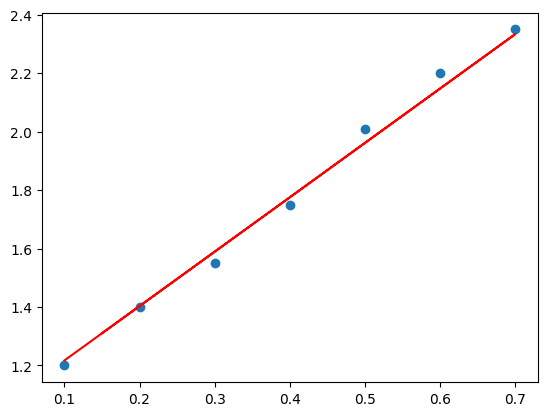

In [13]:
plt.scatter(X,Y)

x1 = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.15]
y1 = [(w*i + b) for i in x1]
plt.plot(x1, y1, color='r')